In [4]:
import pandas as pd

results_path = 'outputs/ggs/results/RandomForestModel_467bdc30_20260509_1125.csv'


cols_params = ['feature_set', 'window_size', 'n_components', 'clipping_threshold',
               'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 
               'mean_S_score', 'mean_C_index', 'mean_MAE', 'mean_RMSE']

df_results = pd.read_csv(results_path)

total = len(df_results)
exitosas = df_results['mean_S_score'].notna().sum()
fallidas = df_results['mean_S_score'].isna().sum()
n_duplicados = df_results.duplicated(subset=cols_params).sum()

print(f"Total configuraciones: {total}")
print(f"Exitosas:              {exitosas}")
print(f"Fallidas (NaN):        {fallidas}")
print(f"Duplicados:            {n_duplicados}")
print(f"Únicas:                {total - n_duplicados}")

Total configuraciones: 10368
Exitosas:              10368
Fallidas (NaN):        0
Duplicados:            0
Únicas:                10368


In [5]:
df_top = (
    df_results
    .dropna(subset=['mean_S_score'])
    .sort_values('mean_S_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

df_top[cols_params]

,feature_set,window_size,n_components,clipping_threshold,n_estimators,max_depth,min_samples_leaf,max_features,mean_S_score,mean_C_index,mean_MAE,mean_RMSE
0,A,30,20,115,200,NaN,10,1.0,1.883120,0.908693,6.982621,10.621407
1,A,30,20,115,200,10.0,10,1.0,1.888651,0.910075,6.961162,10.583097
2,A,30,20,115,100,10.0,10,1.0,1.891046,0.910163,6.955357,10.586206
3,A,30,20,115,200,NaN,5,1.0,1.891983,0.908016,7.002764,10.654055
4,A,30,20,115,100,NaN,10,1.0,1.893297,0.908422,6.985039,10.636345
5,A,30,20,115,100,NaN,5,1.0,1.898050,0.907910,7.002233,10.667064
6,A,30,20,115,200,10.0,5,1.0,1.898817,0.910293,6.961137,10.597294
7,A,30,15,115,200,10.0,10,1.0,1.900187,0.910782,6.939218,10.612990
8,A,30,15,115,200,NaN,10,1.0,1.901608,0.909682,6.949389,10.651319
9,A,30,20,115,200,NaN,1,1.0,1.902389,0.906617,7.075391,10.712568


In [ ]:
from src.models.random_forest import RandomForestModel
from src.utils.production_predictor import RULProductionPredictor

best_params_rf = {
    'feature_set':        'A',
    'window_size':        30,
    'n_components':       20,
    'clipping_threshold': 115,
    'n_estimators':       100,
    'max_depth':          10, 
    'min_samples_leaf':   10,
    'max_features':       1.0,
}

predictor = RULProductionPredictor.from_config(
    model_class=RandomForestModel,
    params=best_params,
)

print(f"model_name_:        {predictor.model_name_}")
print(f"feature_set:        {predictor.feature_set}")
print(f"window_size:        {predictor.window_size}")
print(f"n_components:       {predictor.n_components}")
print(f"clipping_threshold: {predictor.clipping_threshold}")
print(f"pipeline fitted:    {predictor.pipeline_.is_fitted_}")
print(f"model fitted:       {getattr(predictor.model_, 'is_fitted_', False)}")

Training engines: 140
Test engines: 60
model_name_:        RandomForestModel
feature_set:        A
window_size:        30
n_components:       20
clipping_threshold: 115
pipeline fitted:    True
model fitted:       True


In [8]:
# Métricas del ganador del RF
dt_metrics = {
    'mean_S_score': 1.891046,
    'mean_C_index': 0.910163,
    'mean_MAE':     6.955357,
    'mean_RMSE':    10.586206,
}

session_dt = predictor.save(metrics=dt_metrics)

print(f"\nstem:     {session_dt.stem}")
print(f"modelo:   {session_dt.path_model}")
print(f"metadata: {session_dt.path_metadata}")

  ✅ Predictor saved: RandomForestModel_A_30w_20pc_20260510_2159.pkl
  📄 Metadata saved: RandomForestModel_A_30w_20pc_20260510_2159.json

stem:     RandomForestModel_A_30w_20pc_20260510_2159
modelo:   outputs/production/models/RandomForestModel_A_30w_20pc_20260510_2159.pkl
metadata: outputs/production/metadata/RandomForestModel_A_30w_20pc_20260510_2159.json


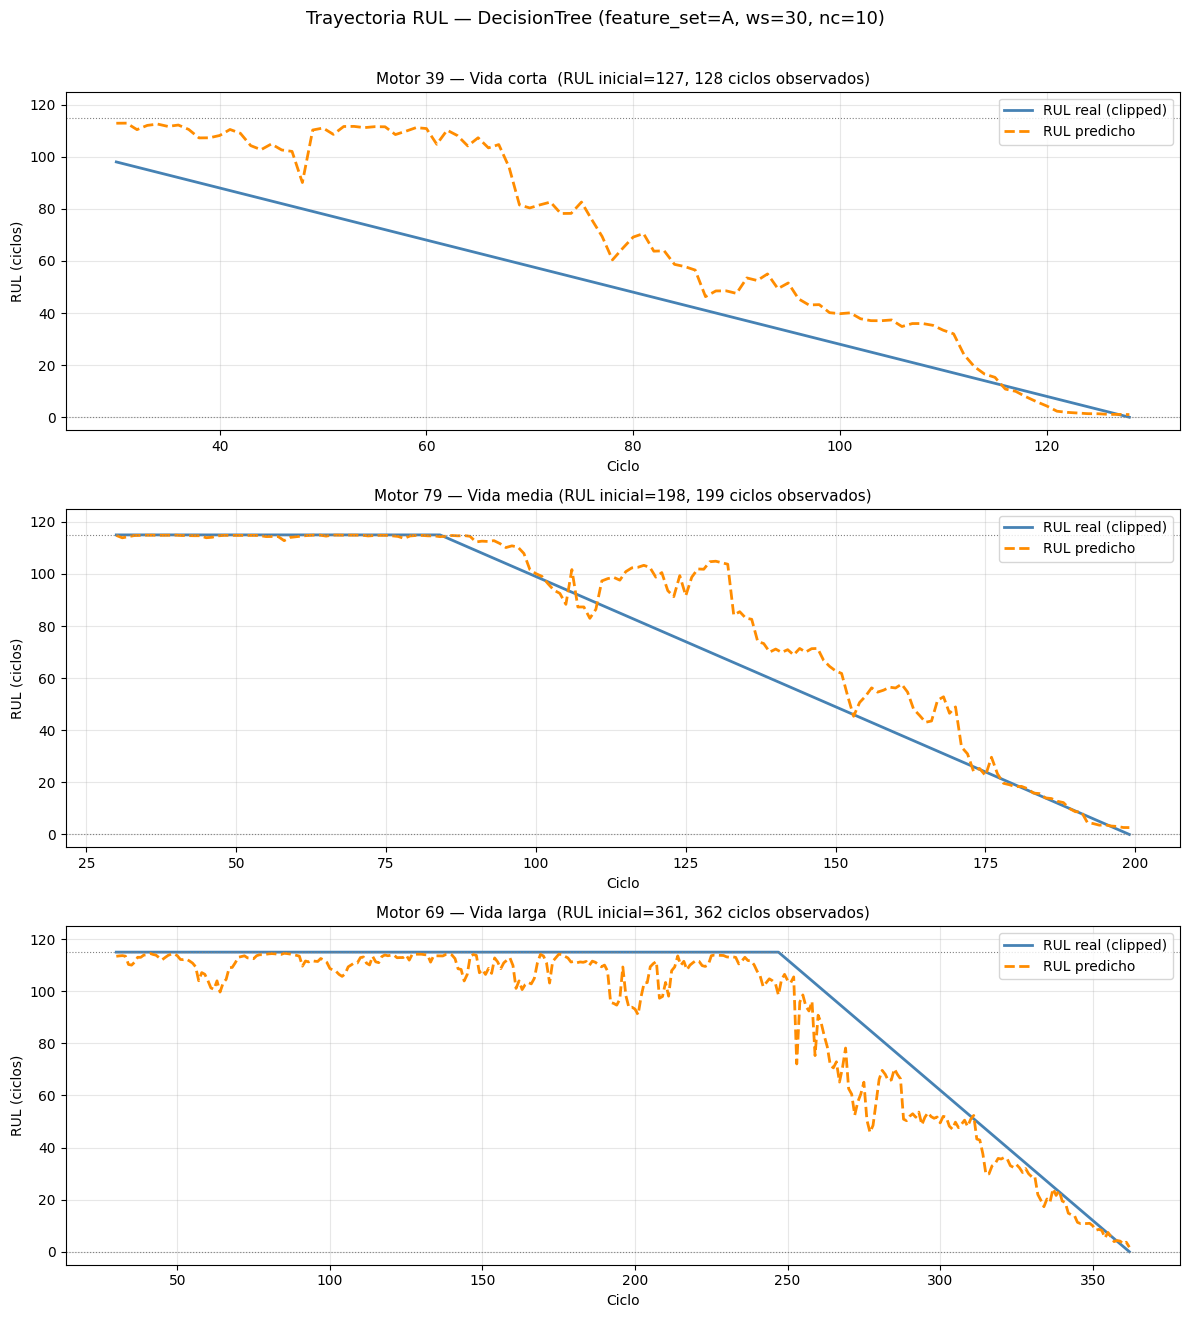

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

motores = [
    (39, 'Vida corta  (RUL inicial=127, 128 ciclos observados)'),
    (79, 'Vida media (RUL inicial=198, 199 ciclos observados)'),
    (69, 'Vida larga  (RUL inicial=361, 362 ciclos observados)'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 13))

for ax, (motor_id, titulo) in zip(axes, motores):
    df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
    df_m.insert(0, 'unit_number', motor_id)
    X_m = df_m.drop(columns=['RUL'])

    _, _, t_stop_m, _, _ = predictor.pipeline_.transform(X_m)
    rul_pred_m = predictor.predict(X_m, return_mode='all')

    rul_real_m = np.minimum(
        df_m['RUL'].values[predictor.window_size - 1:],
        predictor.clipping_threshold,
    )

    ax.plot(t_stop_m, rul_real_m, label='RUL real (clipped)', color='steelblue',  linewidth=2)
    ax.plot(t_stop_m, rul_pred_m, label='RUL predicho',       color='darkorange', linewidth=2, linestyle='--')
    ax.axhline(y=0,                           color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(y=predictor.clipping_threshold, color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(f'Motor {motor_id} — {titulo}', fontsize=11)
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('RUL (ciclos)')
    ax.set_ylim(-5, predictor.clipping_threshold + 10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Trayectoria RUL — DecisionTree (feature_set=A, ws=30, nc=10)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()